In [1]:
import pandas as pd
import numpy as np

In [4]:
yield_df = pd.read_csv(r"C:\Users\Shiva Teja\Downloads\archive (9)\crop_yield.csv")
crop_df = pd.read_csv(r"C:\Users\Shiva Teja\Downloads\archive (8)\Crop_recommendation.csv")


In [5]:
print("Crop Recommendation Dataset Loaded:", crop_df.shape)
print("Crop Yield Dataset Loaded:", yield_df.shape)

Crop Recommendation Dataset Loaded: (2200, 8)
Crop Yield Dataset Loaded: (19689, 10)


In [6]:
def validate_dataset(df, dataset_name):
    print("=" * 60)
    print(f"DATA VALIDATION: {dataset_name}")
    print("=" * 60)

    print("\n1. Dataset Shape:")
    print(df.shape)

    print("\n2. Column Names:")
    print(df.columns.tolist())

    print("\n3. Data Types:")
    print(df.dtypes)

    print("\n4. Missing Values:")
    print(df.isnull().sum())

    print("\n5. Total Missing Values:")
    print(df.isnull().sum().sum())

    print("\n6. Duplicate Rows:")
    print(df.duplicated().sum())

    print("\n7. Summary Statistics:")
    print(df.describe())

In [7]:
validate_dataset(crop_df, "Crop Recommendation")

DATA VALIDATION: Crop Recommendation

1. Dataset Shape:
(2200, 8)

2. Column Names:
['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

3. Data Types:
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

4. Missing Values:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

5. Total Missing Values:
0

6. Duplicate Rows:
0

7. Summary Statistics:
                 N            P            K  temperature     humidity  \
count  2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean     50.551818    53.362727    48.149091    25.616244    71.481779   
std      36.917334    32.985883    50.647931     5.063749    22.263812   
min       0.000000     5.000000     5.000000     8.825675    14.258040   
25%      21.000000 

In [8]:
validate_dataset(yield_df, "Crop Yield")

DATA VALIDATION: Crop Yield

1. Dataset Shape:
(19689, 10)

2. Column Names:
['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield']

3. Data Types:
Crop                object
Crop_Year            int64
Season              object
State               object
Area               float64
Production           int64
Annual_Rainfall    float64
Fertilizer         float64
Pesticide          float64
Yield              float64
dtype: object

4. Missing Values:
Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
dtype: int64

5. Total Missing Values:
0

6. Duplicate Rows:
0

7. Summary Statistics:
          Crop_Year          Area    Production  Annual_Rainfall  \
count  19689.000000  1.968900e+04  1.968900e+04     19689.000000   
mean    2009.127584  1.799266e+05  1.643594e+07     

In [9]:
def dataset_summary(df, dataset_name):
    summary = pd.DataFrame({
        "Column": df.columns,
        "Data Type": df.dtypes.astype(str).values,
        "Missing Values": df.isnull().sum().values,
        "Unique Values": df.nunique().values
    })

    print(f"\n{'=' * 60}")
    print(dataset_name)
    print(f"{'=' * 60}")
    print(f"Rows: {df.shape[0]}")
    print(f"Columns: {df.shape[1]}")
    print(f"Duplicate Rows: {df.duplicated().sum()}")

    display(summary)

In [10]:
dataset_summary(crop_df, "Crop Recommendation Dataset")


Crop Recommendation Dataset
Rows: 2200
Columns: 8
Duplicate Rows: 0


,Column,Data Type,Missing Values,Unique Values
0,N,int64,0,137
1,P,int64,0,117
2,K,int64,0,73
3,temperature,float64,0,2200
4,humidity,float64,0,2200
5,ph,float64,0,2200
6,rainfall,float64,0,2200
7,label,object,0,22


In [11]:
dataset_summary(yield_df, "Crop Yield Dataset")



Crop Yield Dataset
Rows: 19689
Columns: 10
Duplicate Rows: 0


,Column,Data Type,Missing Values,Unique Values
0,Crop,object,0,55
1,Crop_Year,int64,0,24
2,Season,object,0,6
3,State,object,0,30
4,Area,float64,0,13644
5,Production,int64,0,14016
6,Annual_Rainfall,float64,0,634
7,Fertilizer,float64,0,18598
8,Pesticide,float64,0,17405
9,Yield,float64,0,13551


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

print(crop_df["label"].value_counts())

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


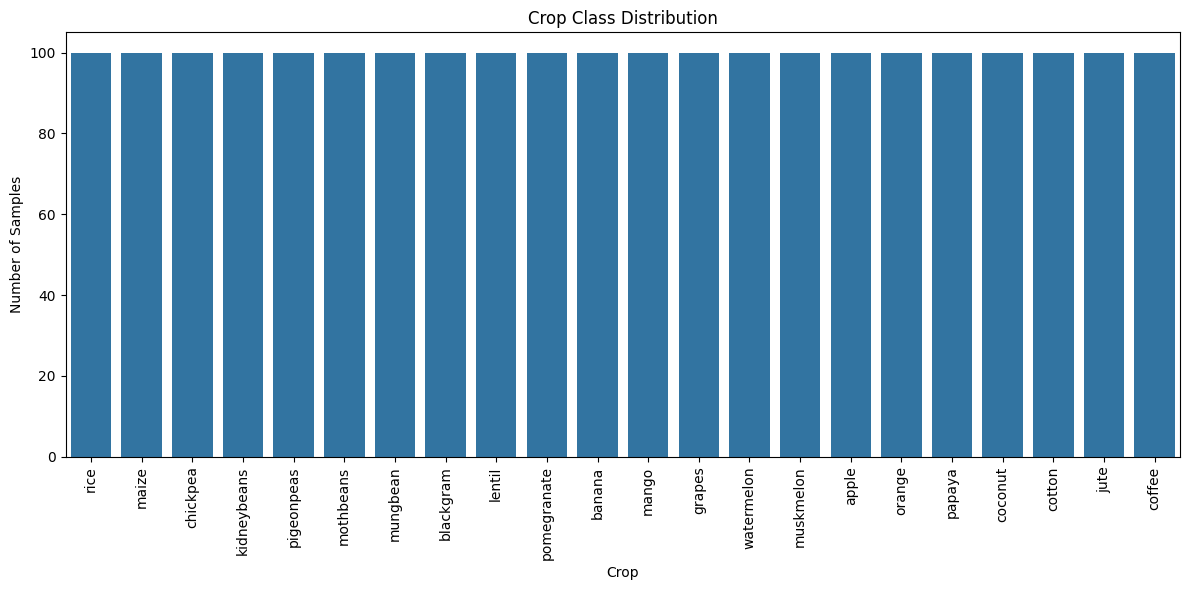

In [13]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=crop_df,
    x="label",
    order=crop_df["label"].value_counts().index
)

plt.xticks(rotation=90)
plt.title("Crop Class Distribution")
plt.xlabel("Crop")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

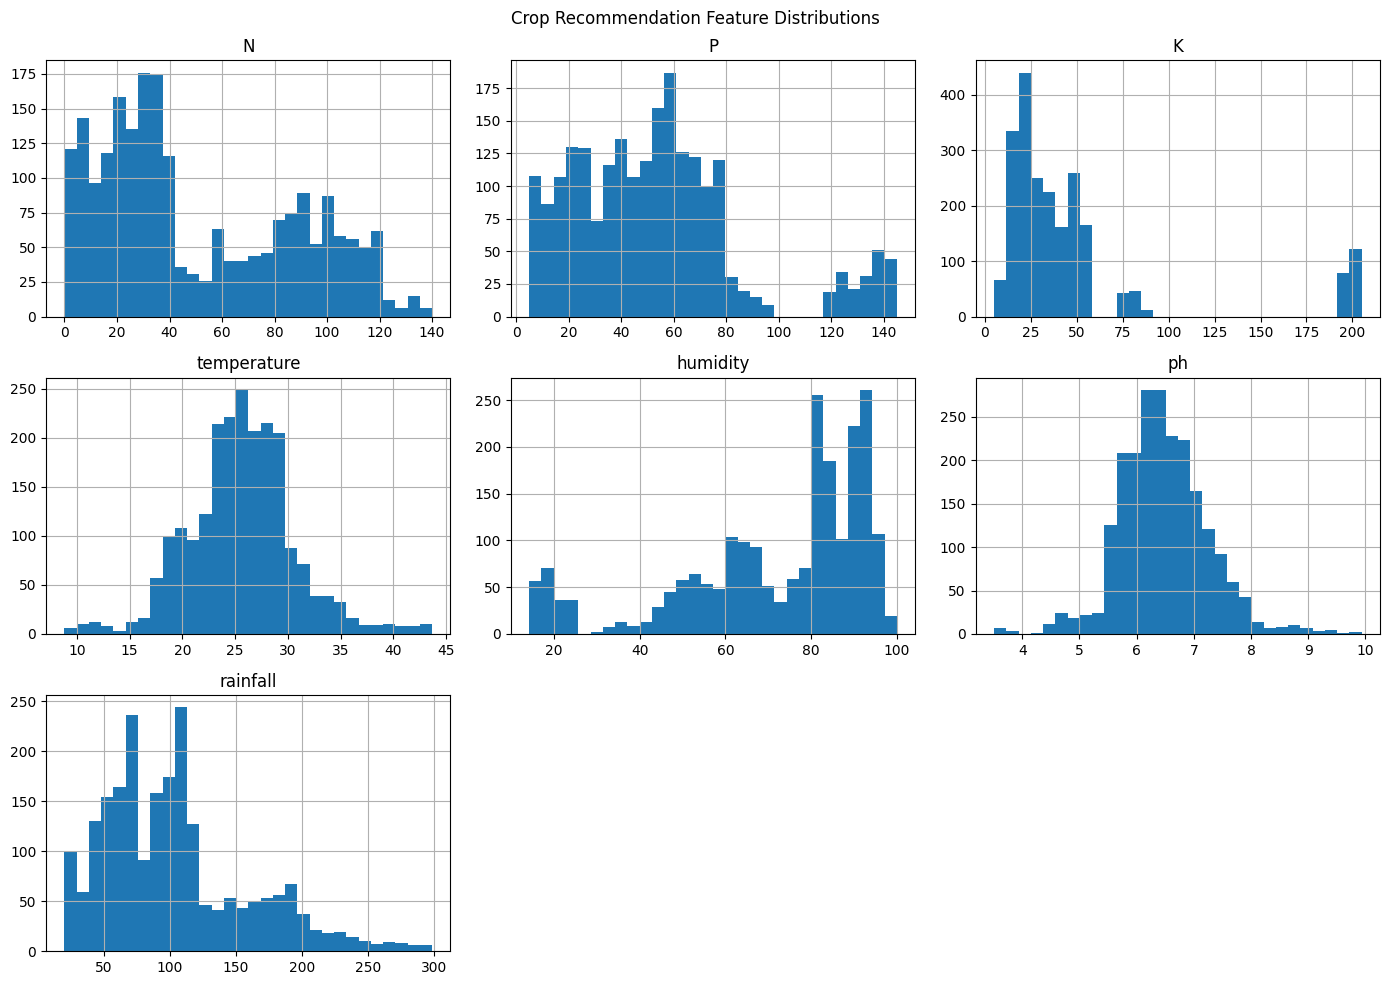

In [14]:
crop_df.hist(
    figsize=(14, 10),
    bins=30
)

plt.suptitle("Crop Recommendation Feature Distributions")
plt.tight_layout()
plt.show()

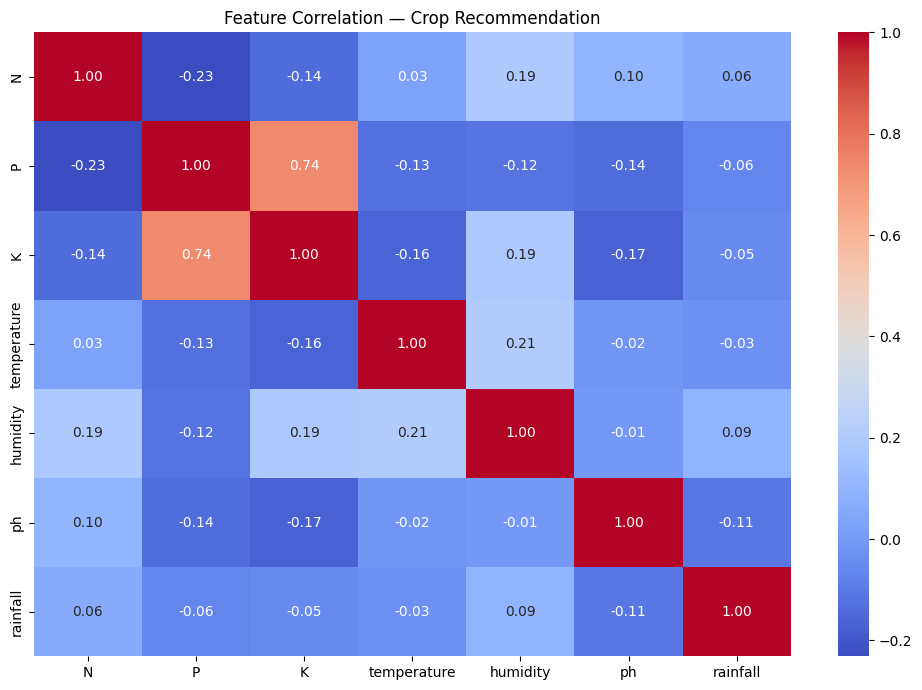

In [15]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    crop_df.drop(columns=["label"]).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation — Crop Recommendation")
plt.tight_layout()
plt.show()

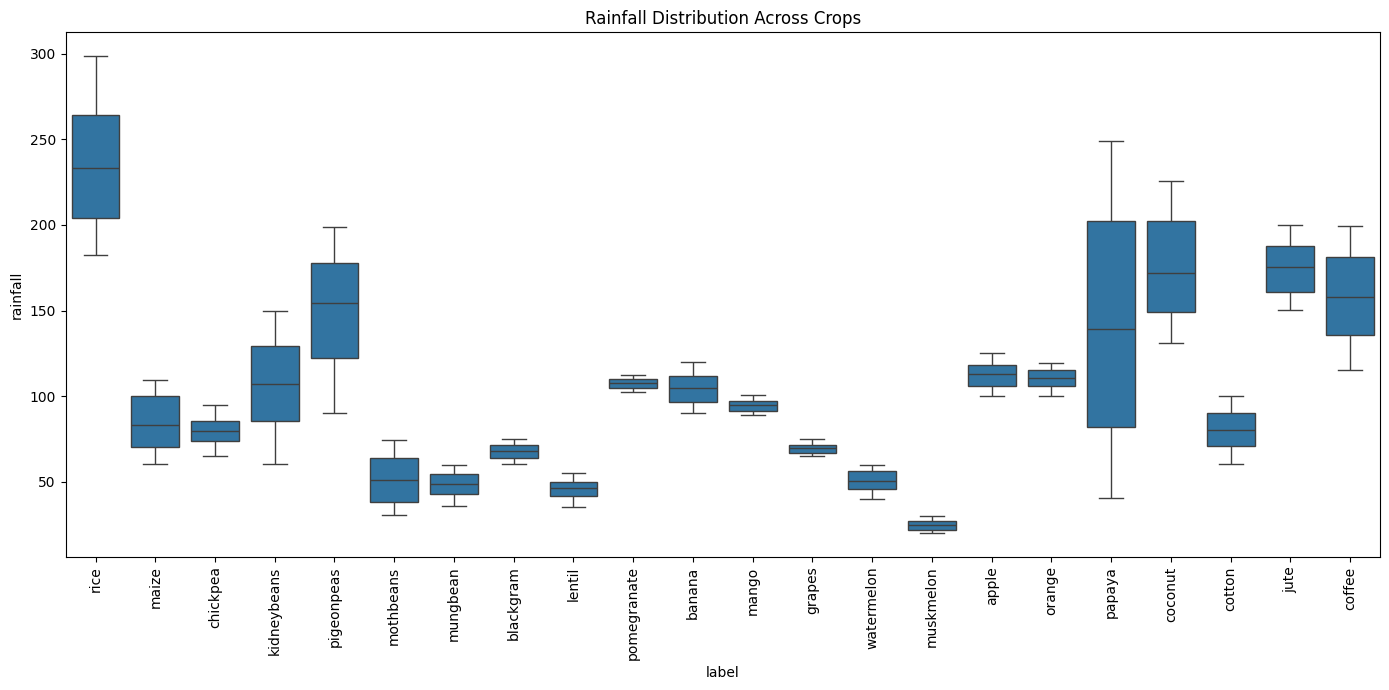

In [16]:
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=crop_df,
    x="label",
    y="rainfall"
)

plt.xticks(rotation=90)
plt.title("Rainfall Distribution Across Crops")
plt.tight_layout()
plt.show()

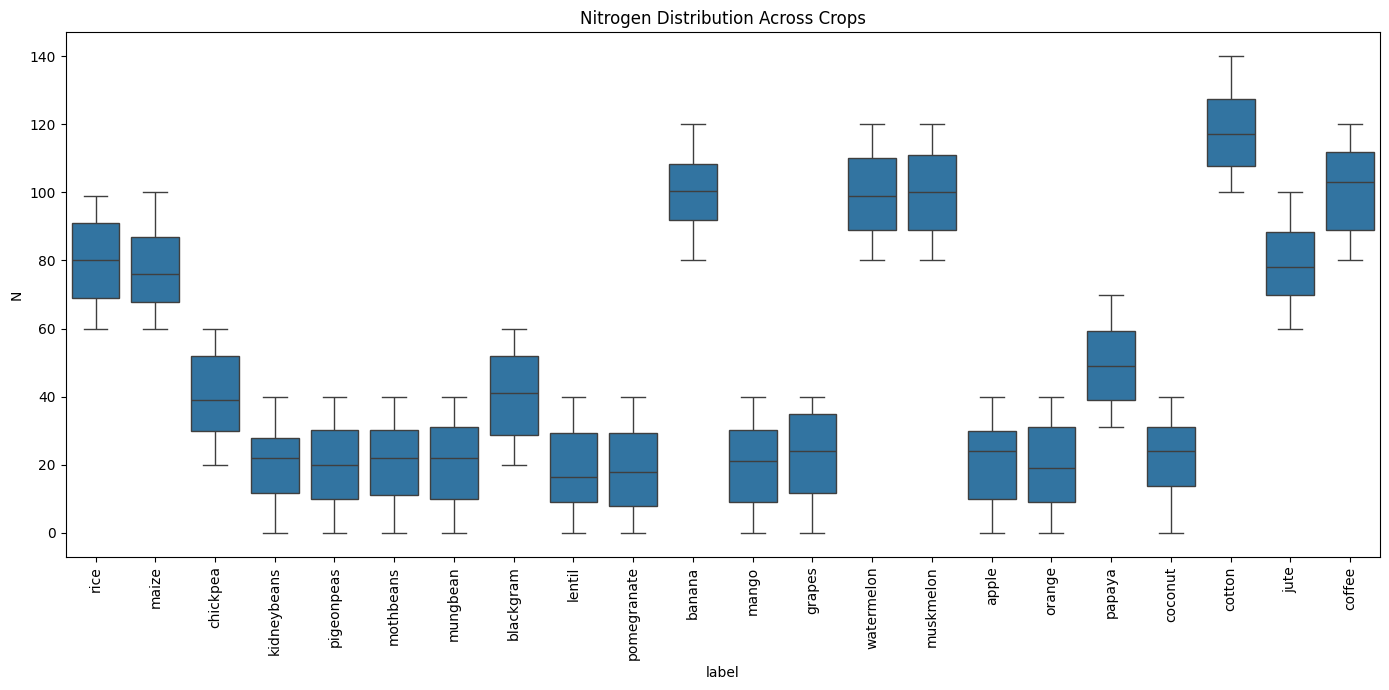

In [17]:
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=crop_df,
    x="label",
    y="N"
)

plt.xticks(rotation=90)
plt.title("Nitrogen Distribution Across Crops")
plt.tight_layout()
plt.show()

In [ ]:
#Part-b
yield_df.describe()

,Crop_Year,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
count,19689.000000,1.968900e+04,1.968900e+04,19689.000000,1.968900e+04,1.968900e+04,19689.000000
mean,2009.127584,1.799266e+05,1.643594e+07,1437.755177,2.410331e+07,4.884835e+04,79.954009
std,6.498099,7.328287e+05,2.630568e+08,816.909589,9.494600e+07,2.132874e+05,878.306193
min,1997.000000,5.000000e-01,0.000000e+00,301.300000,5.417000e+01,9.000000e-02,0.000000
25%,2004.000000,1.390000e+03,1.393000e+03,940.700000,1.880146e+05,3.567000e+02,0.600000
50%,2010.000000,9.317000e+03,1.380400e+04,1247.600000,1.234957e+06,2.421900e+03,1.030000
75%,2015.000000,7.511200e+04,1.227180e+05,1643.700000,1.000385e+07,2.004170e+04,2.388889
max,2020.000000,5.080810e+07,6.326000e+09,6552.700000,4.835407e+09,1.575051e+07,21105.000000


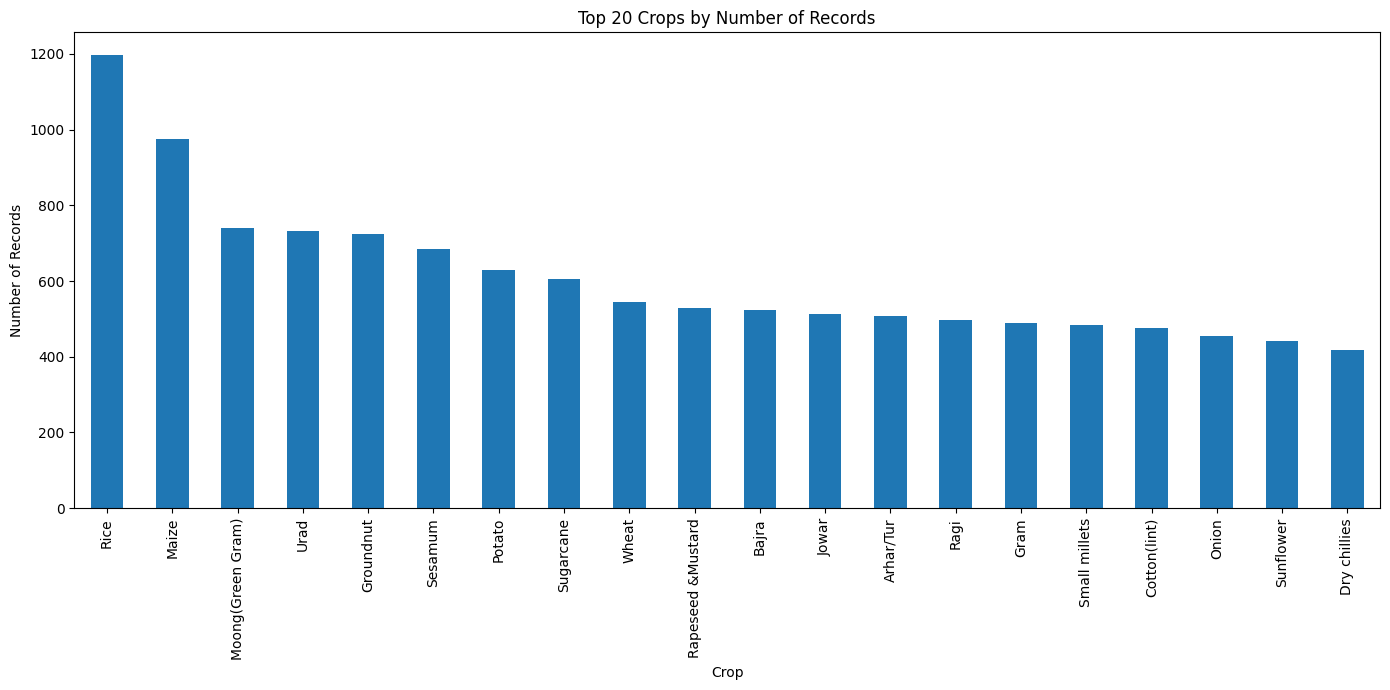

In [19]:
plt.figure(figsize=(14, 7))

yield_df["Crop"].value_counts().head(20).plot(kind="bar")

plt.title("Top 20 Crops by Number of Records")
plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

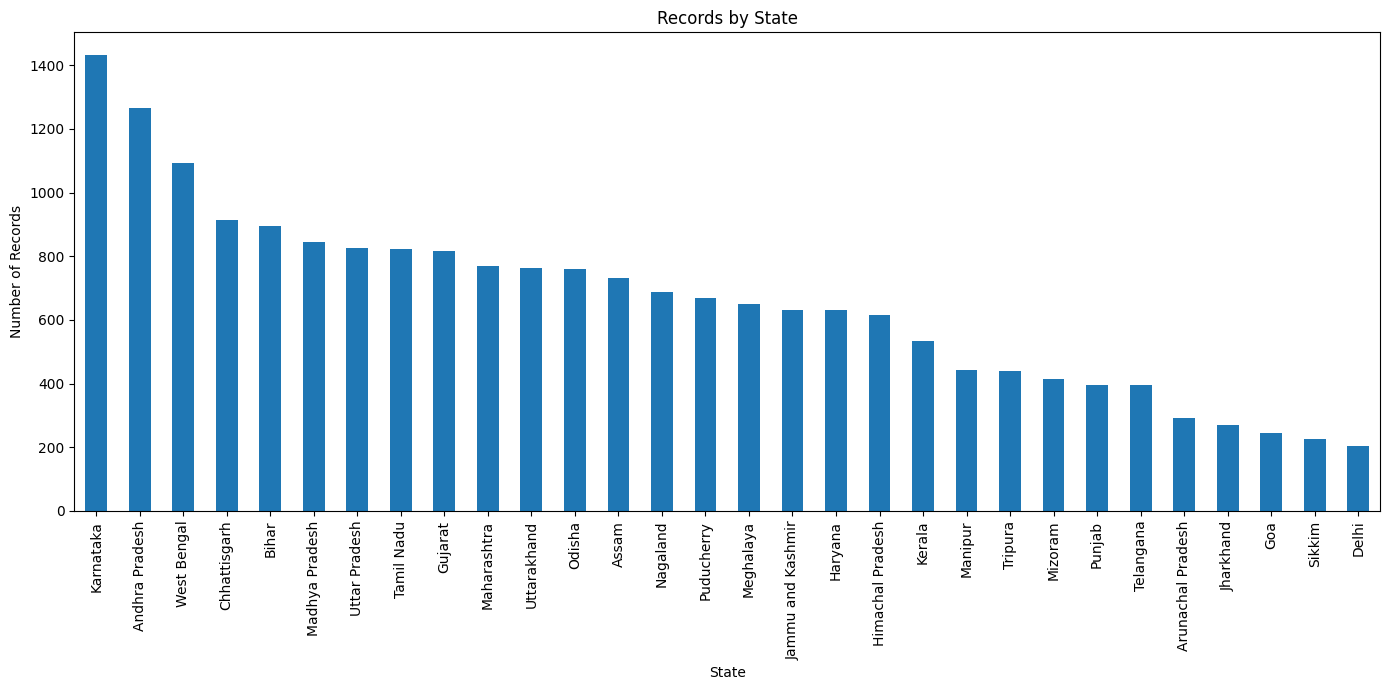

In [20]:
plt.figure(figsize=(14, 7))

yield_df["State"].value_counts().plot(kind="bar")

plt.title("Records by State")
plt.xlabel("State")
plt.ylabel("Number of Records")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [21]:
yield_df[["Area", "Production", "Yield"]].corr()

,Area,Production,Yield
Area,1.000000,0.037441,0.001858
Production,0.037441,1.000000,0.570809
Yield,0.001858,0.570809,1.000000


In [22]:
yield_df[["Area", "Production", "Yield"]].describe()

,Area,Production,Yield
count,1.968900e+04,1.968900e+04,19689.000000
mean,1.799266e+05,1.643594e+07,79.954009
std,7.328287e+05,2.630568e+08,878.306193
min,5.000000e-01,0.000000e+00,0.000000
25%,1.390000e+03,1.393000e+03,0.600000
50%,9.317000e+03,1.380400e+04,1.030000
75%,7.511200e+04,1.227180e+05,2.388889
max,5.080810e+07,6.326000e+09,21105.000000


In [23]:
yield_df[
    ["Crop", "Area", "Production", "Yield"]
].head(20)

,Crop,Area,Production,Yield
0,Arecanut,73814.0,56708,0.796087
1,Arhar/Tur,6637.0,4685,0.710435
2,Castor seed,796.0,22,0.238333
3,Coconut,19656.0,126905000,5238.051739
4,Cotton(lint),1739.0,794,0.420909
5,Dry chillies,13587.0,9073,0.643636
6,Gram,2979.0,1507,0.465455
7,Jute,94520.0,904095,9.919565
8,Linseed,10098.0,5158,0.461364
9,Maize,19216.0,14721,0.615652


In [24]:
print(yield_df["Crop_Year"].min())
print(yield_df["Crop_Year"].max())

1997
2020


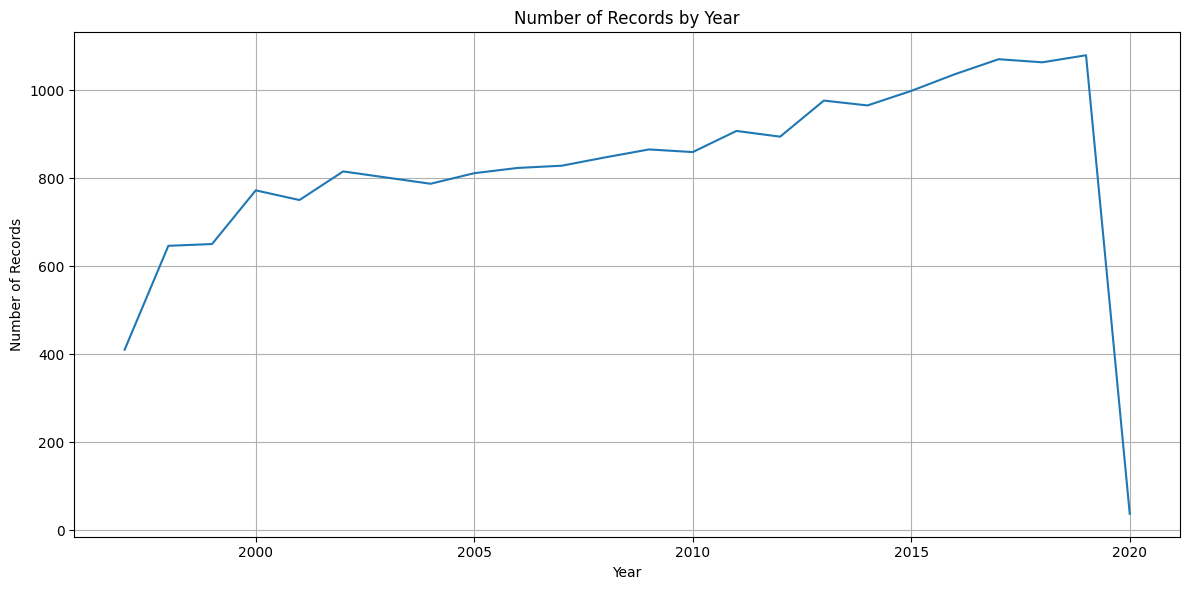

In [25]:
year_counts = yield_df["Crop_Year"].value_counts().sort_index()

plt.figure(figsize=(12, 6))

year_counts.plot()

plt.title("Number of Records by Year")
plt.xlabel("Year")
plt.ylabel("Number of Records")
plt.grid(True)
plt.tight_layout()
plt.show()